# Forecasting Predicted Maternal Mortality Rates (2023-2040)

In [41]:
# Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [42]:
# Load the dataset and filter for maternal causes of death

mm = pd.read_csv(r'C:\Users\Monchelle\OneDrive\Documents\Data Visualization Learning\maternal-mortality\data\cleaned_maternal_mortality.csv')
mm = mm[mm['icd10_113_cause_list'].str.contains("O00", na=False)] # This filters for maternal causes of death based on ICD-10 codes starting with "O00"

mm_national = (
    mm.groupby(['year', 'race'], as_index=False)
            .agg({'deaths': 'sum', 'population': 'sum'})
) # Create a national-level summary by year and race

mm_national['crude_rate'] = (mm_national['deaths'] / mm_national['population']) * 100000 # Calculate the national crude maternal mortality rate per 100,000 population

mm_national.head()


,year,race,deaths,population,crude_rate
0,1999,Black or African American,71.0,12393393.0,0.572886
1,1999,White,105.0,87303724.0,0.120270
2,2000,Black or African American,45.0,10815231.0,0.416080
3,2000,White,112.0,82822517.0,0.135229
4,2001,Black or African American,81.0,12970952.0,0.624472


In [43]:
# Subset the necessary columns for analysis

df = mm_national[['year', 'race', 'crude_rate']]

df.head()

,year,race,crude_rate
0,1999,Black or African American,0.572886
1,1999,White,0.120270
2,2000,Black or African American,0.416080
3,2000,White,0.135229
4,2001,Black or African American,0.624472


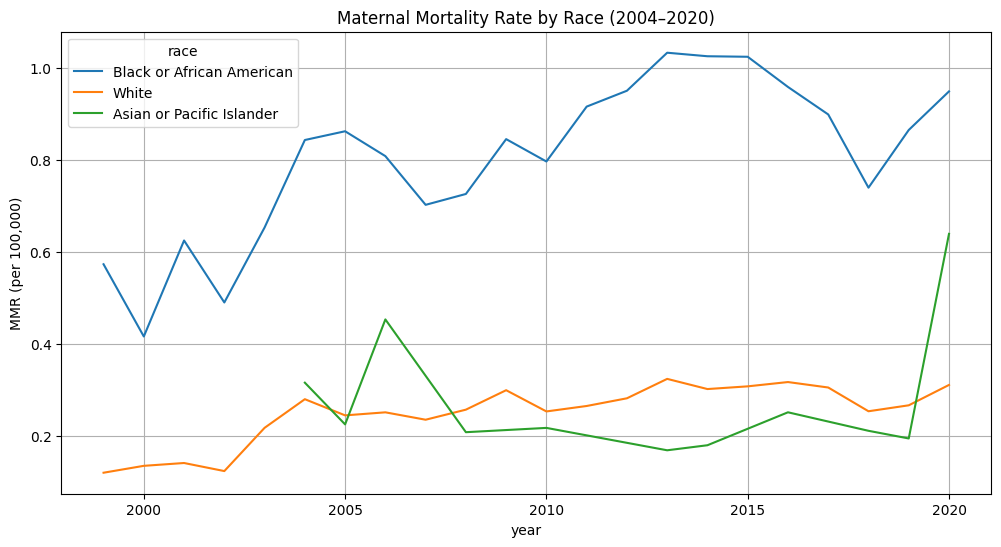

In [44]:
# Visualize Trends

plt.figure(figsize=(12,6))
sb.lineplot(data=df, x='year', y='crude_rate', hue='race')
plt.title("Maternal Mortality Rate by Race (2004–2020)")
plt.ylabel("MMR (per 100,000)")
plt.grid(True)
plt.show()

In [45]:
# Build Polynomial Regression Model for Future Predictions by Race

future_years = np.array(range(2021, 2035)).reshape(-1, 1)

poly = PolynomialFeatures(degree=2) 

predictions = []

for race in df['race'].unique():
    df_race = df[df['race'] == race].dropna(subset=['crude_rate'])
    X = df_race[['year']]
    y = df_race['crude_rate']

    # Transform the features to include polynomial terms
    X_poly = poly.fit_transform(X)

    # Fit the linear regression model
    model = LinearRegression()
    model.fit(X_poly, y)

    # Predict for future years
    future_poly = poly.transform(future_years)
    future_predictions = model.predict(future_poly)

    # Store predictions for each race
    for year, pred in zip(future_years.flatten(), future_predictions):
        predictions.append({
            'race' : race,
            'year' : year,
            'predicted_crude_rate' : pred
        })

pred_df = pd.DataFrame(predictions)
pred_df.head()

c:\Users\Monchelle\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\Monchelle\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\Monchelle\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


,race,year,predicted_crude_rate
0,Black or African American,2021,0.862432
1,Black or African American,2022,0.837897
2,Black or African American,2023,0.809660
3,Black or African American,2024,0.777722
4,Black or African American,2025,0.742081


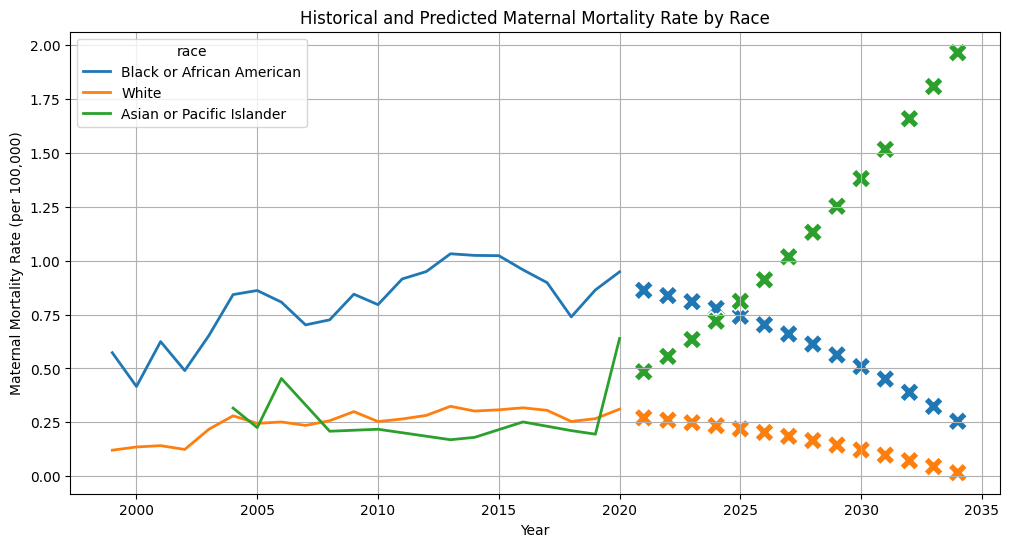

In [46]:
# Visualize Future Predictions

# Plot historical data
plt.figure(figsize=(12, 6))
sb.lineplot(data=df, x='year', y='crude_rate', hue='race', linewidth=2)

# Plot future predictions
sb.scatterplot(data=pred_df, x='year', y='predicted_crude_rate', hue='race', marker='X', s=200, legend=False)
               
plt.title("Historical and Predicted Maternal Mortality Rate by Race")
plt.ylabel("Maternal Mortality Rate (per 100,000)")
plt.xlabel("Year")
plt.grid(True)
plt.show()

In [47]:
# Export predictions to CSV

pred_df.to_csv("mmr_polynomial_forecast.csv", index=False)

#### The predictions of the model do not seem logical or realistic, so we should attempt to test a linear regression to see if this provides more realistic predictiosn for the data.

In [48]:
# Create a Linear Regression Model to Predict Maternal Mortality Rates by Race

predictions_linear = []

for race in df['race'].unique():
    df_race = df[df['race'] == race].dropna(subset=['crude_rate'])
    X = df_race[['year']]
    y = df_race['crude_rate']

    model = LinearRegression()
    model.fit(X, y)

    future_predictions = model.predict(future_years)

    for year, pred in zip(future_years.flatten(), future_predictions):
        predictions_linear.append({
            'race' : race,
            'year' : year,
            'predicted_crude_rate' : pred
        })

pred_linear_df = pd.DataFrame(predictions_linear)
pred_linear_df

c:\Users\Monchelle\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Monchelle\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Monchelle\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,race,year,predicted_crude_rate
0,Black or African American,2021,1.032720
1,Black or African American,2022,1.052608
2,Black or African American,2023,1.072496
3,Black or African American,2024,1.092384
4,Black or African American,2025,1.112272
5,Black or African American,2026,1.132161
6,Black or African American,2027,1.152049
7,Black or African American,2028,1.171937
8,Black or African American,2029,1.191825
9,Black or African American,2030,1.211713


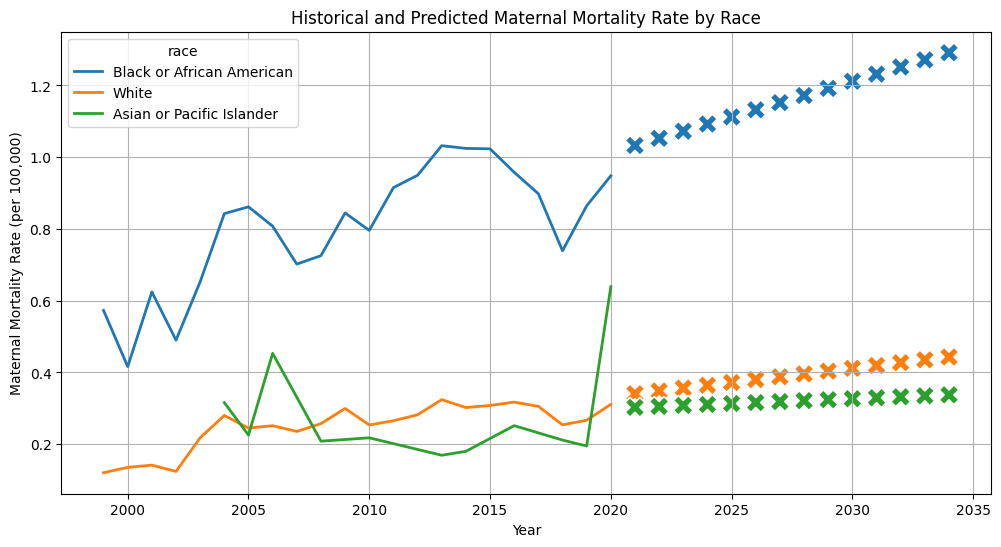

In [49]:
# Visualize Future Predictions

# Plot historical data
plt.figure(figsize=(12, 6))
sb.lineplot(data=df, x='year', y='crude_rate', hue='race', linewidth=2)

# Plot future predictions
sb.scatterplot(data=pred_linear_df, x='year', y='predicted_crude_rate', hue='race', marker='X', s=200, legend=False)
plt.title("Historical and Predicted Maternal Mortality Rate by Race")
plt.ylabel("Maternal Mortality Rate (per 100,000)")
plt.xlabel("Year")
plt.grid(True)
plt.show()

In [50]:
# Export linear predictions to CSV

pred_linear_df.to_csv("mmr_linear_forecast.csv", index=False)